# Introduction 

The goal of this exercise is to classify leaf images into 3 classes. The classes or lables are, basil, Chinar  and lemon. THe leaf images are sourced from a dataset in kaggle. The pictures are rgb images and each image is processed independently. I applied quite a few machine learning techniques to complete this exercise. For feature extraction, i extraced color features like mean and variance of RGB channels, second order texture features using GLCM and template matching for each class. other than that, to understand the features and the corelations between them, I used pairplots, correlation matrix, histograms and principal component analysis. After that, I trained and finetunned 3 different classifiers using GridSearchCV with Stratified K-Fold. Which were Ridge classifier, Random Forest Classifier and MLP. Finally, I got the performance of each classifier using nested cross-validation.

# Data Preparation

In [1]:
#imports
import numpy as np
import pandas as pd
import os
import cv2
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
#data read
labels = ["Basil", "Chinar", "Lemon"]
images = []
y = []
all_path = []
for label in labels:
    path = os.path.join("/home/scp619/MLPR/MLPR Execercise/", label)
    all_path.append(path)
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        data = cv2.imread(img_path)
        images.append(data)
        y.append(label)

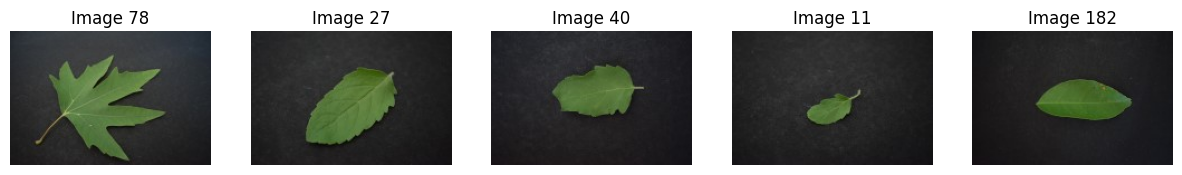

In [3]:
# data print
random_imgs = random.sample(range(len(images)), 5)
plt.figure(figsize=(15, 5))
for i, id in enumerate(random_imgs):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(images[id], cv2.COLOR_BGR2RGB))
    plt.title(f"Image {id}")
    plt.axis("off")

In [4]:
#data preparation
# i need to do these for every image so ill ill do all 3 in 1 loop.
img_rgb = []
img_gs = []
img_qt = []
for img in images:
    img_rgb_temp = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img_rgb.append(img_rgb_temp)
    img_gs_temp = cv2.cvtColor(img_rgb_temp,cv2.COLOR_RGB2GRAY)
    img_gs.append(img_gs_temp)
    img_qt_temp = img_gs_temp // 32
    img_qt.append(img_qt_temp)



RGB shape: (120, 180, 3)
Gray shape: (120, 180)
Quantized Max: 5
Quantized Min: 0


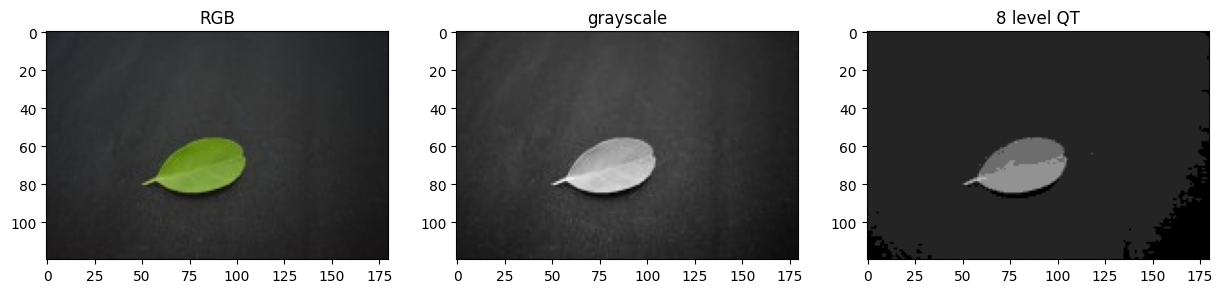

In [5]:
#i know that theoritically my code in data prep is correct. but iam making sure that I did them right.
random_img_id = random.randint(0,len(img_rgb)-1)

print("RGB shape:", img_rgb[random_img_id].shape)  
print("Gray shape:", img_gs[random_img_id].shape)  
print("Quantized Max:", np.max(img_qt[random_img_id]))
print("Quantized Min:", np.min(img_qt[random_img_id]))

#plot
fig,ax = plt.subplots(1,3, figsize = (15,3))
ax[0].imshow(img_rgb[random_img_id])
ax[0].set_title("RGB")
ax[0].axis = False

ax[1].imshow(img_gs[random_img_id],cmap = 'gray')
ax[1].set_title("grayscale")
ax[1].axis = False

ax[2].imshow(img_qt[random_img_id],cmap='gray', vmin=0, vmax=7)
ax[2].set_title("8 level QT")
ax[2].axis = False

plt.show()

In [6]:
#feature Extraction
#color features for RGB
feature_list = []
template_ids = [28, 69, 153]
basil_tm = img_gs[template_ids[0]]
chinar_tm = img_gs[template_ids[1]]
lemon_tm = img_gs[template_ids[2]]  

for i in range(len(images)):
    img_rgb_temp = img_rgb[i]
    img_qt_temp = img_qt[i]

    
    #taking the means and var for rgb img
    mean_r = np.mean(img_rgb_temp[:,:,0])
    mean_g = np.mean(img_rgb_temp[:,:,1])
    mean_b = np.mean(img_rgb_temp[:,:,2])
    
    var_r = np.var(img_rgb_temp[:,:,0])
    var_g = np.var(img_rgb_temp[:,:,1])
    var_b = np.var(img_rgb_temp[:,:,2])
    #now for the second order texture mesures I need to first make the gray level co-occurence matrix. 
    # distance 1 and 2 at horizontal and vertical.
    glcm = graycomatrix(img_qt_temp,distances=[1,2],angles=[0, np.pi/2], levels=8, symmetric=True, normed=True) 

    correlation = graycoprops(glcm,'correlation')
    
    correlation_horizontal1 = correlation[0,0]
    correlation_horizontal2 = correlation[1,0]

    correlation_vertical1 = correlation[0,1]
    correlation_vertical2 = correlation[1,1]

    #template matching and maximum response

    # i have to append the features at the same time so that all the features are added in the same row for each image.
    #so even though I worked on the template matching later, I will add that part of the codes here.
    res_basil = cv2.matchTemplate(img_gs[i], basil_tm, cv2.TM_CCOEFF_NORMED)
    res_chinar = cv2.matchTemplate(img_gs[i], chinar_tm, cv2.TM_CCOEFF_NORMED)
    res_lemon = cv2.matchTemplate(img_gs[i], lemon_tm, cv2.TM_CCOEFF_NORMED)

    score_basil = np.max(res_basil)
    score_chinar = np.max(res_chinar)
    score_lemon = np.max(res_lemon)

    feature_list.append([mean_r,mean_g,mean_b,var_r,var_g,var_b,correlation_horizontal1,correlation_horizontal2,correlation_vertical1,correlation_vertical2,score_basil,score_chinar,score_lemon])


In [7]:
print(f"feature rows: {len(feature_list)}")
print(f"labels in y: {len(y)}")

feature rows: 184
labels in y: 184


# Explian what the correlation feature measures.

Answer: 
the qt images have smooth areas or areas with different patterns. when the correlation is high that means the pixel pattern is more predictable. this could be the leaf itself or the background. on the other hand if the correlation is low then that means the pixel pattern is more unpredictable. this maybe because of noisy texture. This can teach the model to differentiate between different parts of the images like a dark background and the leaves. So basically this feature measures how a pixels value is compared to other pixels near it.
another thing I should say is since the correlation is for both horizontal and vertical, using these features, the model can learn to notice the roughness on the leaf along a direction.  


For the template maching, I tried to first choose an image for each class by myself rather than randomly using an id to get an image and use that as the template. But I think the orientation of the leaf in the image might be an issue. for example, In the case of chinar, a most of the images have random orientations. So I am just choosing the images based on if the leaf is centered or not and if I can notice some features in the grayscaled versions myself.

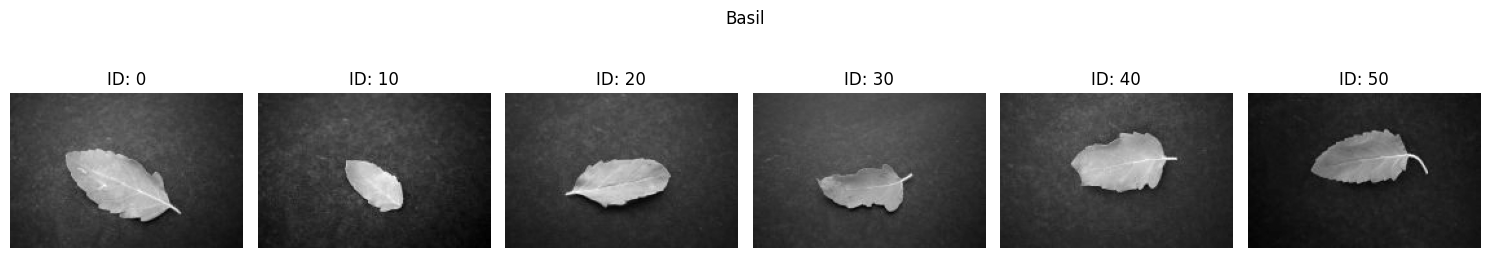

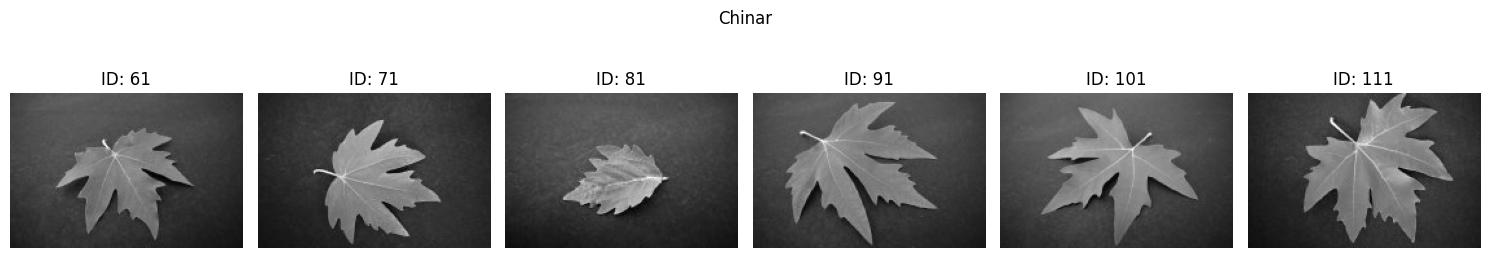

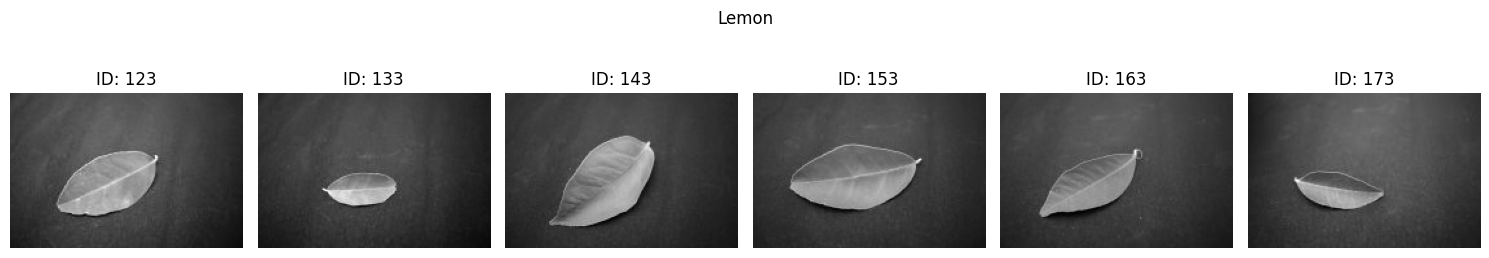

In [8]:
def show_gallery(start_idx, title):
    plt.figure(figsize=(15, 3))
    for i in range(6):
        idx = start_idx + (i * 10)
        plt.subplot(1, 6, i + 1)
        plt.imshow(img_gs[idx], cmap='gray')
        plt.title(f"ID: {idx}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_gallery(0, "Basil")
show_gallery(61, "Chinar")
show_gallery(123, "Lemon")

Basil ID 28,
chinar ID 69,
lemon ID 153

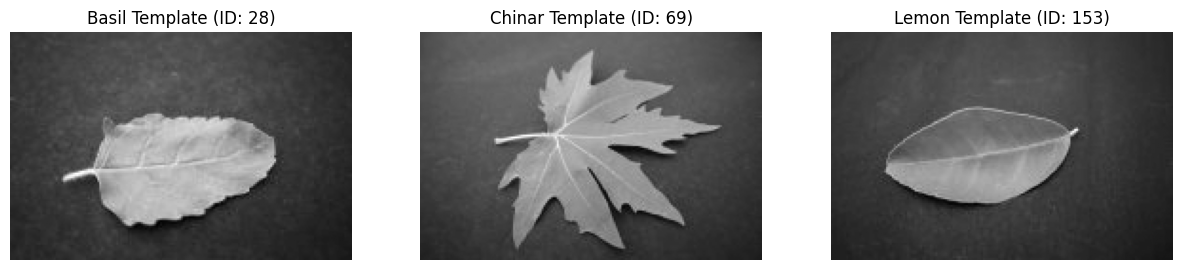

In [9]:
#chosen templates
template_ids = [28, 69, 153]
template_names = ["Basil", "Chinar", "Lemon"]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(template_ids):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img_gs[idx], cmap='gray')
    plt.title(f"{template_names[i]} Template (ID: {idx})")
    plt.axis('off')
plt.show()

# Explain why template matching may help classification

Answer: For every class I am choosing an image to compare all the other images with. This gives me a similarity score of how similar an image is to the template. this is called template matching. Since I am comparing every image with templates from all classes, the highest similarity among these classes may be the actual target class. So the features or scores from template matching can help the leaf classification.

In [22]:
#feature relationships
#ill work with a df from here rather than np arrays. code is easier this way.

column_names = ['mean_r','mean_g','mean_b','var_r','var_g','var_b','correlation_horizontal1','correlation_horizontal2','correlation_vertical1','correlation_vertical2','score_basil','score_chinar','score_lemon']
df = pd.DataFrame(feature_list,columns=column_names)
df['target'] = y

scaler = StandardScaler()

features_scaled = scaler.fit_transform(df.drop('target',axis=1))

df_scaled = pd.DataFrame(features_scaled, columns=column_names)
df_scaled['target'] = df['target']
le = LabelEncoder()
#replacing 'Basil', 'Chinar', 'Lemon' with numbers
y = le.fit_transform(df_scaled['target'])
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_r                   184 non-null    float64
 1   mean_g                   184 non-null    float64
 2   mean_b                   184 non-null    float64
 3   var_r                    184 non-null    float64
 4   var_g                    184 non-null    float64
 5   var_b                    184 non-null    float64
 6   correlation_horizontal1  184 non-null    float64
 7   correlation_horizontal2  184 non-null    float64
 8   correlation_vertical1    184 non-null    float64
 9   correlation_vertical2    184 non-null    float64
 10  score_basil              184 non-null    float64
 11  score_chinar             184 non-null    float64
 12  score_lemon              184 non-null    float64
 13  target                   184 non-null    int64  
dtypes: float64(13), int64(1)
memory usage

In [11]:
df_scaled.head(5)

,mean_r,mean_g,mean_b,var_r,var_g,var_b,correlation_horizontal1,correlation_horizontal2,correlation_vertical1,correlation_vertical2,score_basil,score_chinar,score_lemon,target
0,-0.441460,-0.449895,-0.565191,-0.181691,0.082754,-0.555212,1.074918,1.273527,1.649439,1.759380,0.892290,0.679346,0.423304,Basil
1,-0.167405,-0.211021,-0.593999,1.208887,0.922370,-0.185353,0.821849,0.948342,1.406246,1.602275,1.804367,0.207656,0.300797,Basil
2,-0.265346,-0.390141,-0.545150,0.521713,0.277568,-0.217582,0.861824,0.960816,0.967578,0.957425,1.185304,0.251508,0.902055,Basil
3,-0.446401,-0.440510,-0.533127,-0.089111,0.227772,-0.348571,0.799831,1.052479,1.028874,1.271542,1.337259,1.049868,1.141478,Basil
4,0.559298,0.404542,0.024494,1.748641,1.450058,0.535789,0.870512,0.888880,1.260581,1.277048,1.360649,0.319851,0.155639,Basil


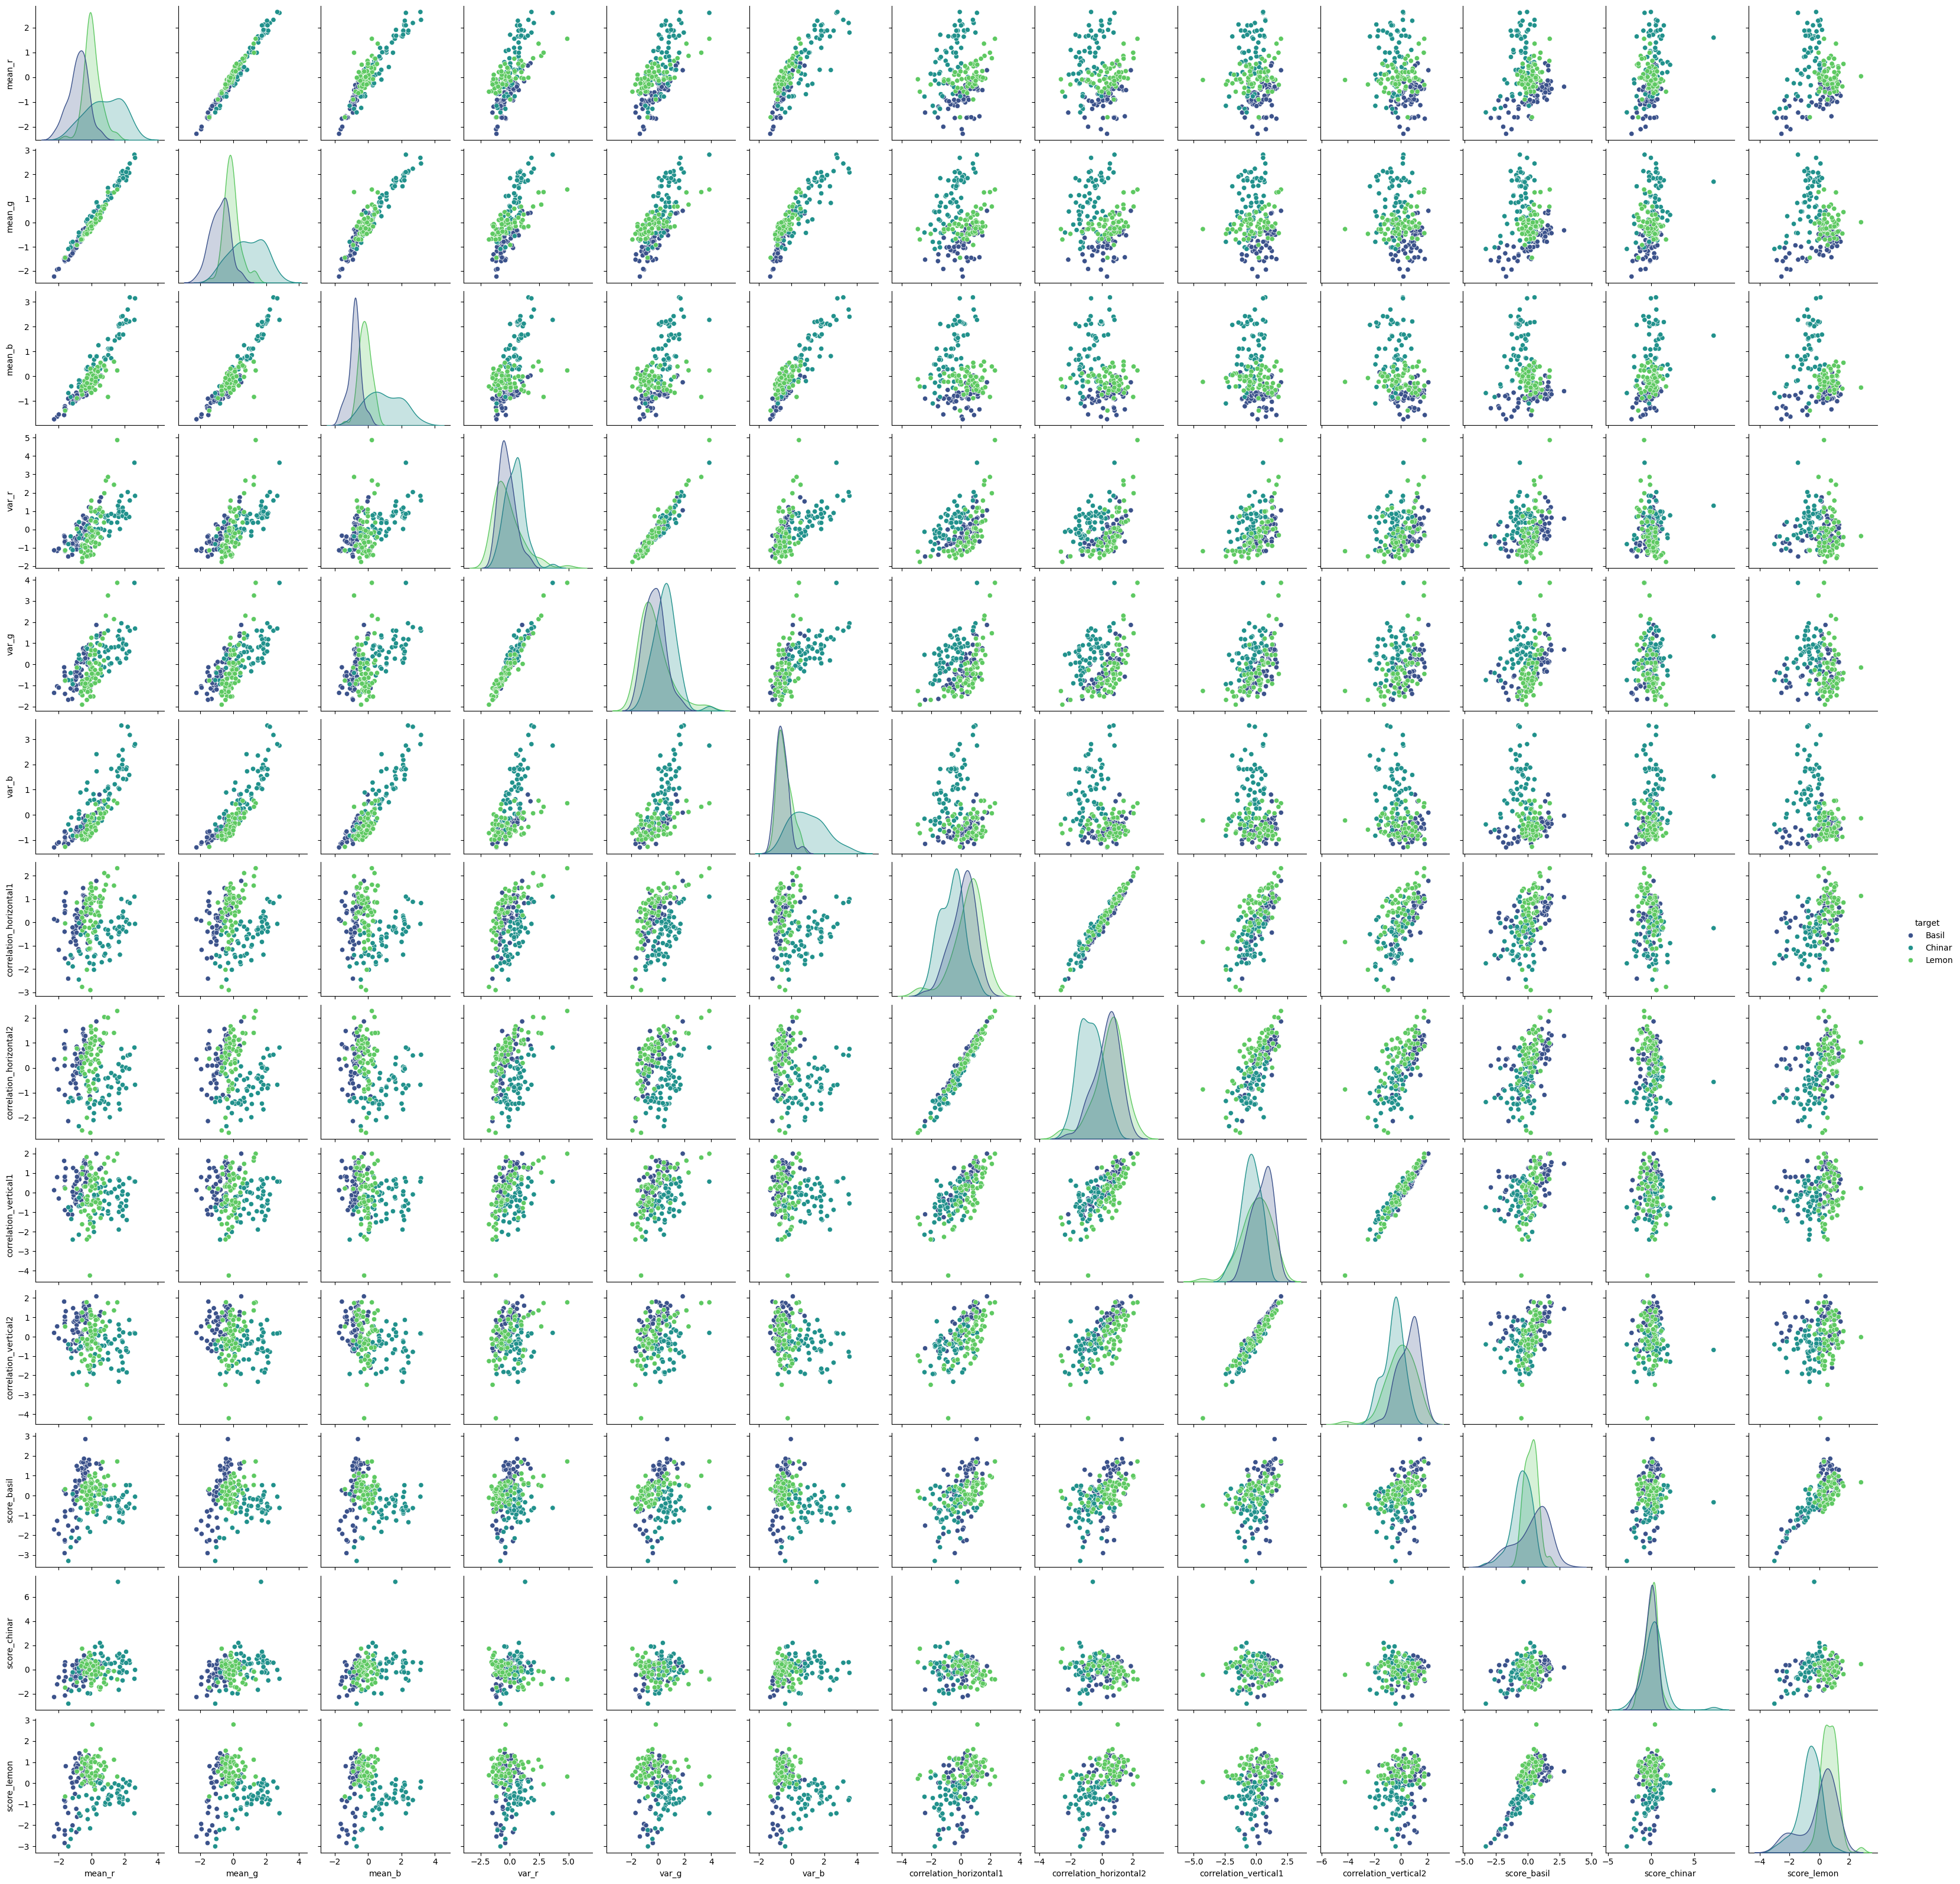

In [12]:
g = sns.pairplot(df_scaled,  hue='target', palette='viridis')
plt.show()

It is more or less impossible to see this 13x13 pair plot and understand anything. I can try to make 4 sections of the pair plots.or I can plot a correlation matrix for the dependencies. I think the later might be the best option here. 

But some things which are a bit more noticable are the plots that look similar to a '/' line. these indicate that the features have a linear dependency. 

But to better write the report, I will make a correlation matrix .

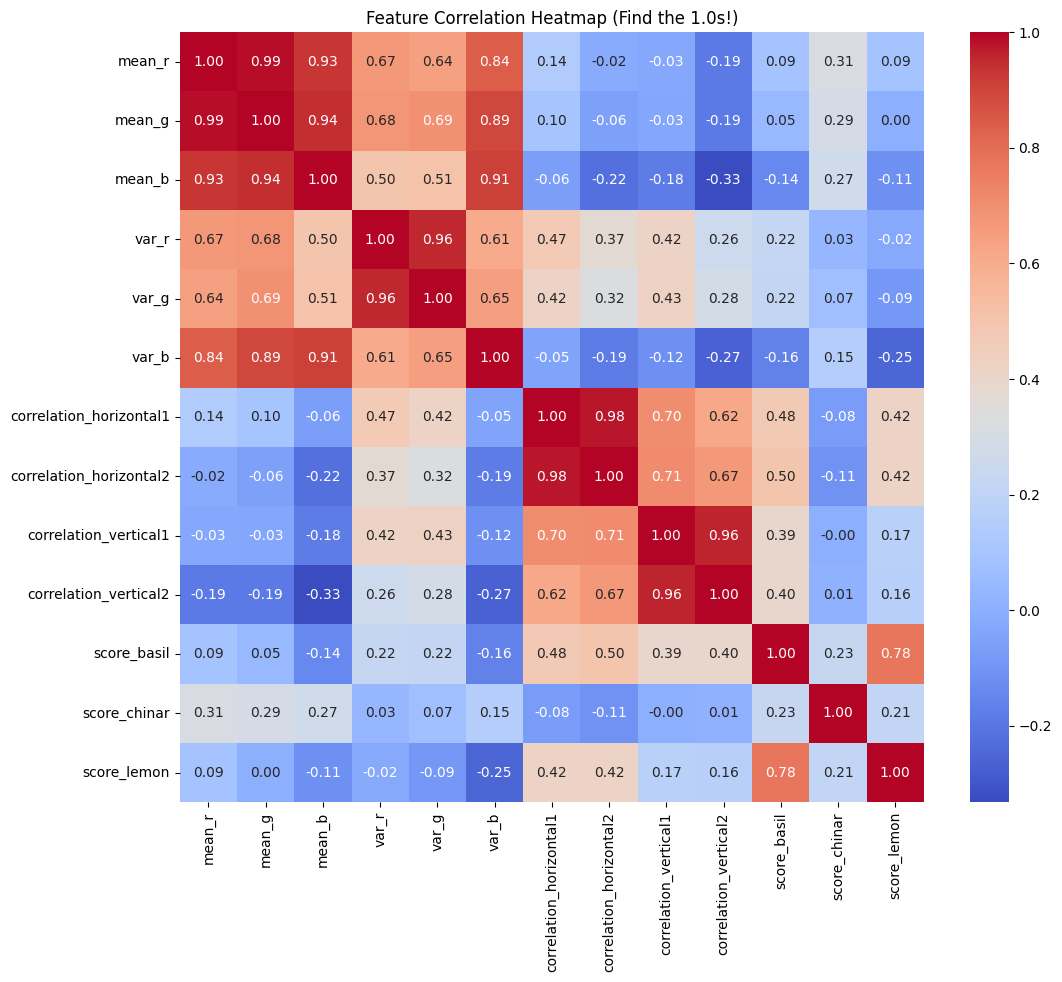

In [13]:
# I think a correlation matrix is better for this than the 13x13 pairplot.
corr_matrix = df_scaled.drop('target', axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (Find the 1.0s!)")
plt.show()

# Which feature pairs show approximately linear dependence?

Answer: From the pairplots which was a bit hard to see and the correlation matrix, I think the four GLCM features have strong linear dependence. The are highly redundant and might have similar data. This is the same for the RGB means as well. 

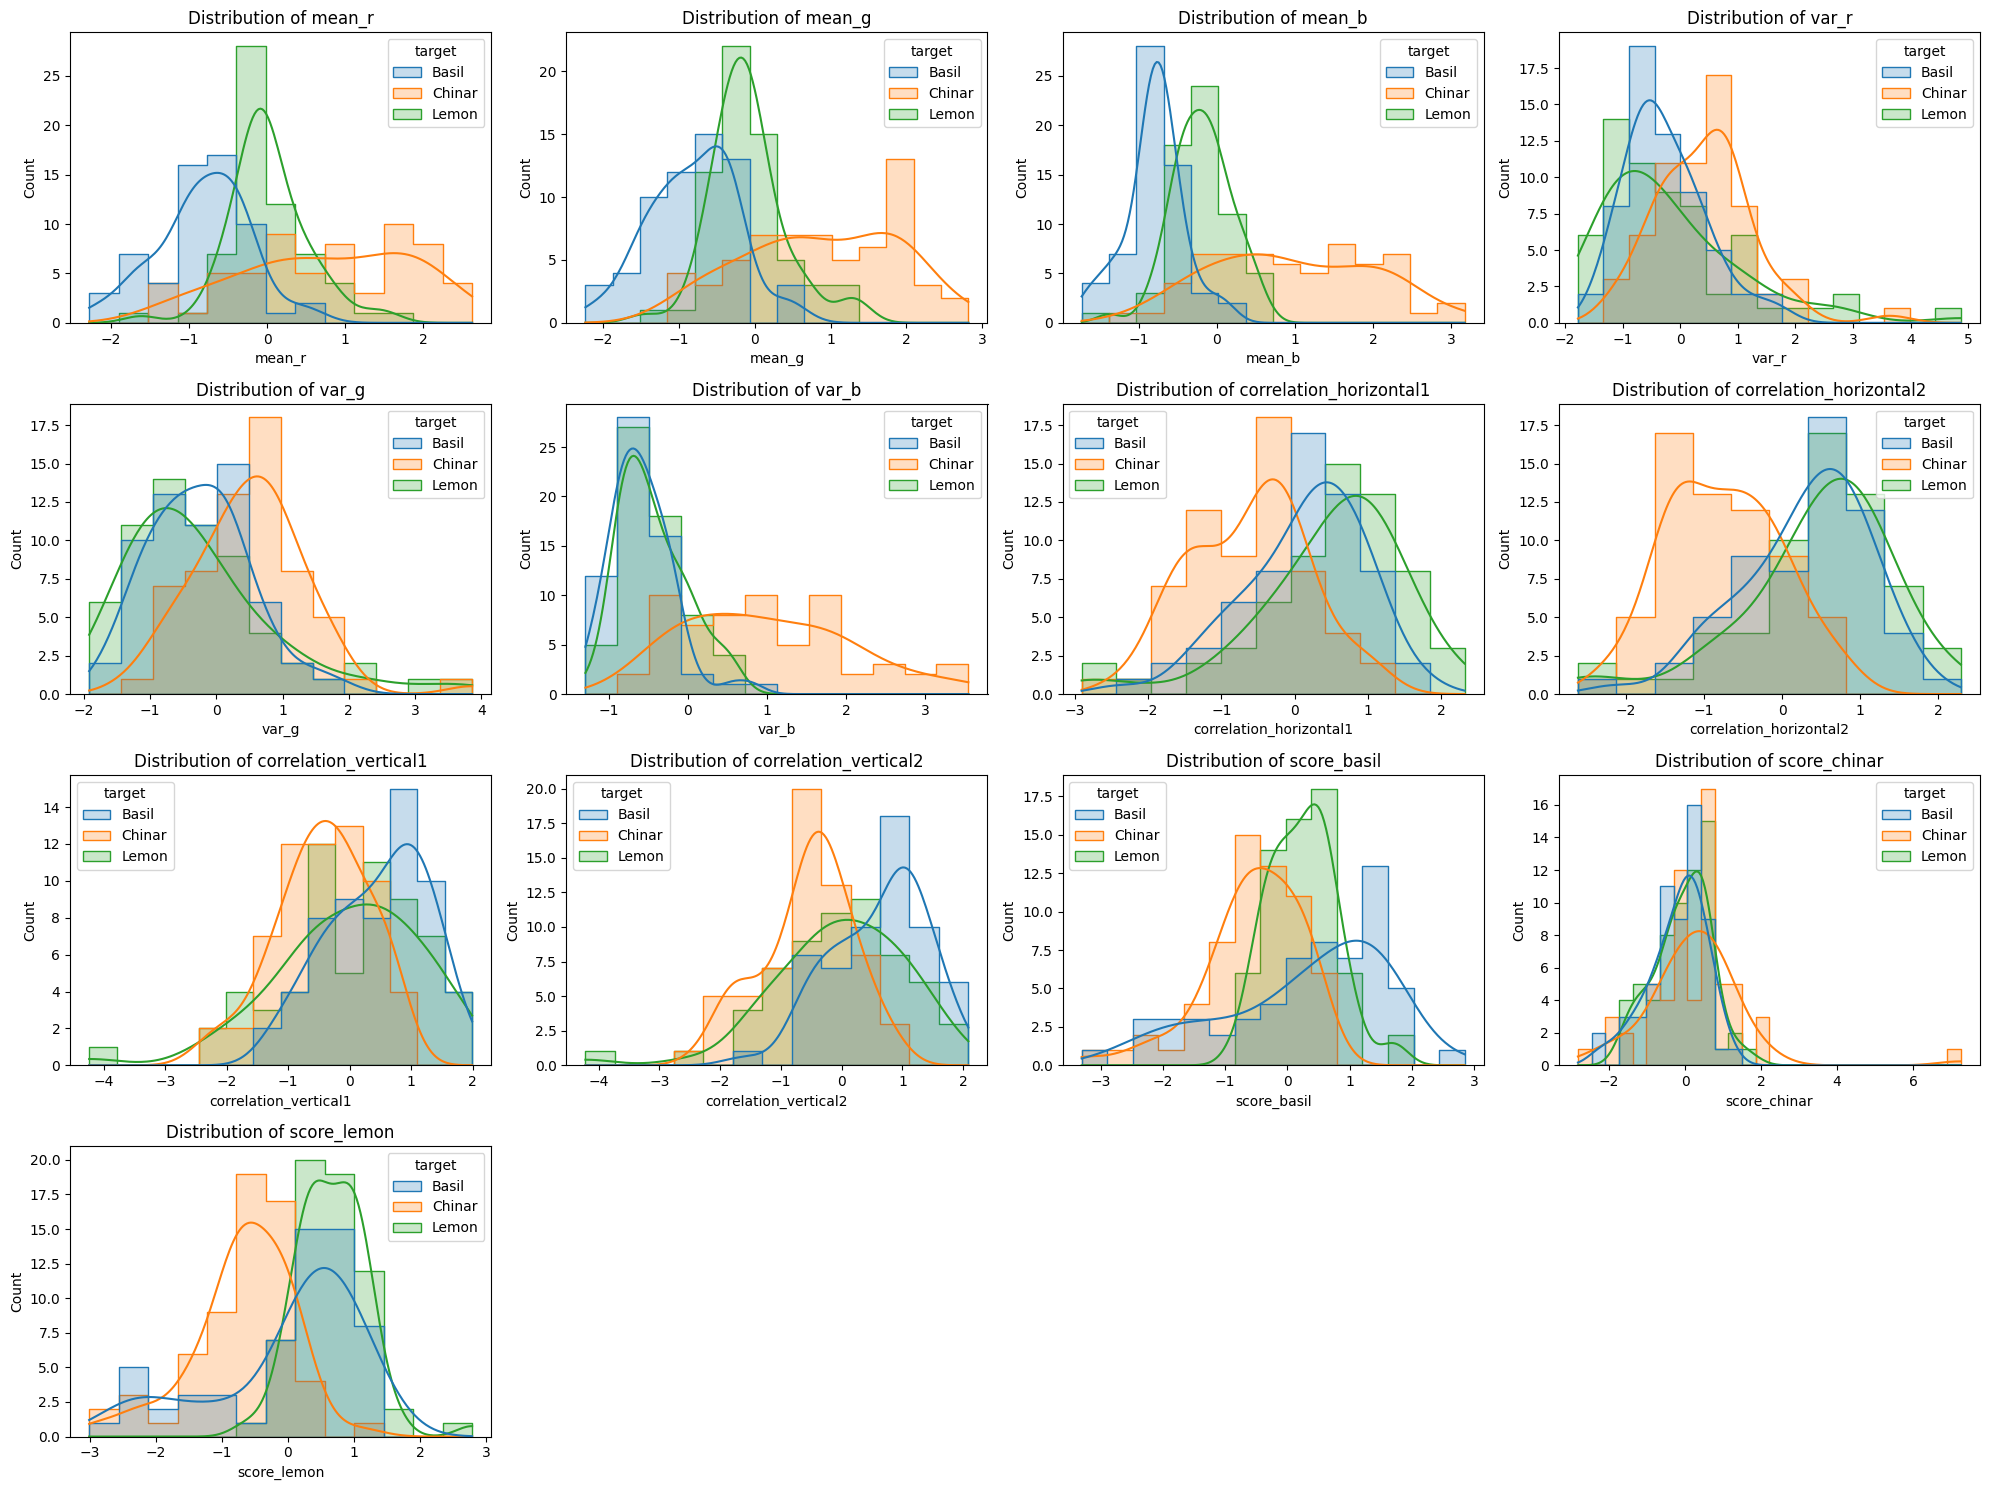

In [14]:
#histograms
plt.figure(figsize=(20, 15))
for i, col in enumerate(column_names):
    plt.subplot(4, 4, i + 1)
    sns.histplot(data=df_scaled, x=col, hue='target', kde=True, element="step")
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Which features seem to have discriminative power?

Answer: So from the histograms I would say that the RGB means have classes that are well seperated. H1 is a bit more separated than H2 but they both have a lot of overlaps in all 3 classes. ANother thing which is a bit suprising is that score basil and score lemon are almost the same plt. maybe since the have a higher linear dependency and are measuring almost the same data. 

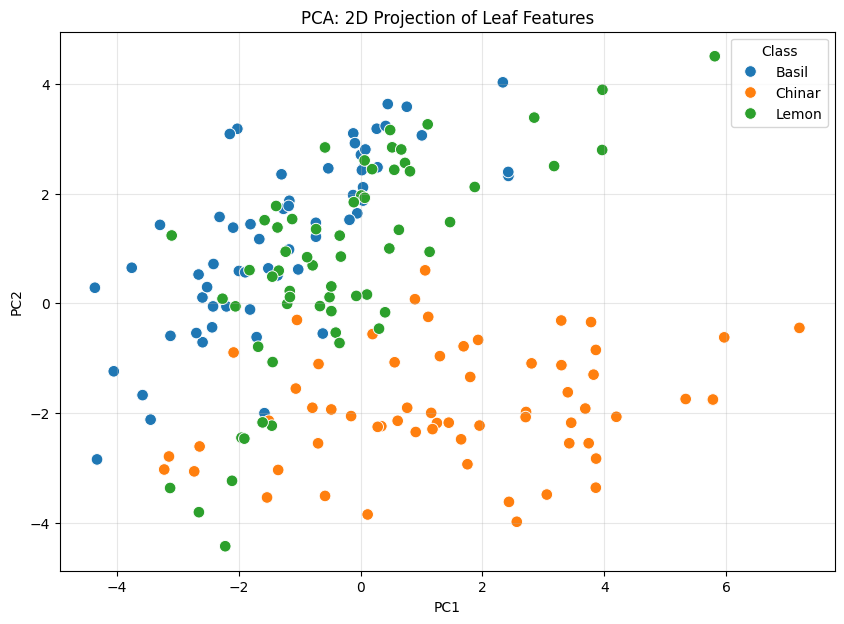

In [ ]:
pca   = PCA(n_components=2)
pca_results = pca.fit_transform(df_scaled.drop('target',axis=1))
df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['Class'] = df_scaled['target']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Class', s=70)
plt.title('PCA: 2D Projection of Leaf Features')
plt.grid(True, alpha=0.3)
plt.show()

# Are the Clusters Noticable? What does PCA suggest about the classification performance?

Answer: The clusters are partially noticable. Chinar cluster is very noticable. but It looks like basil and lemon are overlapping quite a bit. This is what I was afraid of. But Basil cluster is a bit more to the upper left side and the lemon cluster is more in the central area. 

Well in this case, classification performance for Chinar will be high but any model would have a hard time classifying basil and lemon with this data. I think I might have to change the template for basil or lemon to see if this changes anything or not. For now I want to move on to the classification part. If I see that the model is underperforming, I will come back to this.

In [16]:
#classification

#first I will do this for ridge classifier
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0]}

ridge_gridsrCV = GridSearchCV(RidgeClassifier(), ridge_params,
                        cv=cv_inner, scoring='accuracy',return_train_score=True)
ridge_gridsrCV.fit(X, y)

print(f"Best params   : {ridge_gridsrCV.best_params_}")
print(f"Best CV acc   : {ridge_gridsrCV.best_score_:.4f}")

#all tested combinations
ridge_results = pd.DataFrame(ridge_gridsrCV.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
print(ridge_results)

Best params   : {'alpha': 1.0}
Best CV acc   : 0.9242
   param_alpha  mean_test_score  std_test_score
0        0.001         0.918769        0.038010
1        0.010         0.918769        0.038010
2        0.100         0.918769        0.038010
3        1.000         0.924174        0.043075


Best Parameters: {'bootstrap': True, 'max_features': 'sqrt', 'n_estimators': 200}
Best Accuracy: 0.9188
                    Feature  Importance
2                    mean_b    0.161169
0                    mean_r    0.121239
1                    mean_g    0.116562
5                     var_b    0.111228
12              score_lemon    0.106809
7   correlation_horizontal2    0.064471
10              score_basil    0.059611
6   correlation_horizontal1    0.054376
4                     var_g    0.050932
3                     var_r    0.044265
9     correlation_vertical2    0.043002
8     correlation_vertical1    0.037555
11             score_chinar    0.028782


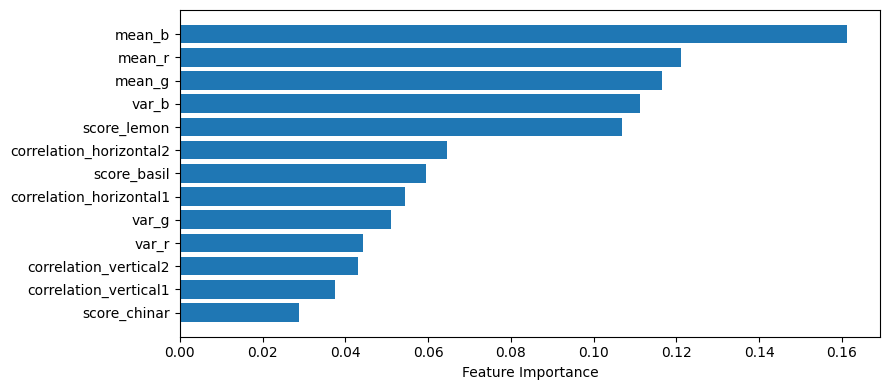

In [17]:
#random fOrest classifier

randomforest_params = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True]
}

randomforest_gridseCV = GridSearchCV(RandomForestClassifier(random_state=69),randomforest_params,cv=cv_inner,scoring='accuracy',n_jobs=1)

randomforest_gridseCV.fit(X,y)

print(f"Best Parameters: {randomforest_gridseCV.best_params_}")
print(f"Best Accuracy: {randomforest_gridseCV.best_score_:.4f}")


importances = randomforest_gridseCV.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': column_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(feature_importance_df['Feature'][::-1], feature_importance_df['Importance'][::-1])
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

# Report feature importance for each feature.
## Which features are the most important?
## Does this match your earlier observations? 


Answer: 
I can see that RGB means are the most significant feautures for the random forest classifier. This is similar to the erlier observations in the histograms where I could see the 3 classes there. Surprisingly, score_chinar is at the bottom. I think even if the template leaf information was not needed for the classifier to make a decision. I think this is good news that the classifiers are getting good validation accuracy. This means things are going according to my thought process. 

In [ ]:
#MLP
mlp_params = {
    'hidden_layer_sizes': [(n,) for n in range(15, 45, 5)],
    'activation'        : ['tanh', 'relu'],
    'solver'            : ['sgd', 'adam'],
    'validation_fraction': [0.1, 0.3],
    'alpha'             : [0.01, 0.1, 1.0]
}
#i had to change the max iter a few times and run the classifier again. was getting a convergence warning where it reached maxiter but was still learning.
mlp_gridsrCV = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=69),
    mlp_params, cv=cv_inner, scoring='accuracy',n_jobs=1)
mlp_gridsrCV.fit(X, y)

print(f"Best params : {mlp_gridsrCV.best_params_}")
print(f"Best CV acc : {mlp_gridsrCV.best_score_:.4f}")

Best params : {'activation': 'tanh', 'alpha': 1.0, 'hidden_layer_sizes': (25,), 'solver': 'adam', 'validation_fraction': 0.1}
Best CV acc : 0.9512


**For each classifier: Best hyperparameters and CV Accuracy**

| Classifier | Best Hyperparameters | CV Accuracy |
|---|---|---|
| Ridge | alpha = 1.0 | 0.9241 |
| Random Forest | n_estimators = 200, max_features = 'sqrt', bootstrap = True | 0.9188 |
| MLP | hidden_layer_sizes = (25,), activation = 'tanh', solver = 'adam', alpha = 1.0, validation_fraction = 0.1 | 0.9512 |

In [19]:
# NESTED CV
cv_outer = StratifiedKFold(n_splits=4, shuffle=True, random_state=69)

def run_nested_analysis(name, model, param_grid):
    print(name)
    grid_search = GridSearchCV(model, param_grid, cv=cv_inner, scoring='accuracy', n_jobs=-1)

    outer_scores = cross_val_score(grid_search, X, y, cv=cv_outer)

    y_pred = cross_val_predict(grid_search, X, y, cv=cv_outer)
    grid_search.fit(X, y)
    
    print(f"Mean Outer Accuracy: {np.mean(outer_scores):.4f}")
    print(f"Standard Deviation: {np.std(outer_scores):.4f}")
    print(f"Selected Hyperparameters: {grid_search.best_params_}")
    
    return outer_scores, y_pred, grid_search.best_params_

ridge_res = run_nested_analysis("Ridge", RidgeClassifier(), ridge_params)
rf_res = run_nested_analysis("Random Forest", RandomForestClassifier(random_state=42), randomforest_params)
mlp_res = run_nested_analysis("MLP", MLPClassifier(max_iter=2000, random_state=69), mlp_params)

Ridge
Mean Outer Accuracy: 0.9076
Standard Deviation: 0.0237
Selected Hyperparameters: {'alpha': 1.0}
Random Forest
Mean Outer Accuracy: 0.8967
Standard Deviation: 0.0495
Selected Hyperparameters: {'bootstrap': True, 'max_features': 'sqrt', 'n_estimators': 200}
MLP
Mean Outer Accuracy: 0.9130
Standard Deviation: 0.0344
Selected Hyperparameters: {'activation': 'tanh', 'alpha': 1.0, 'hidden_layer_sizes': (25,), 'solver': 'adam', 'validation_fraction': 0.1}


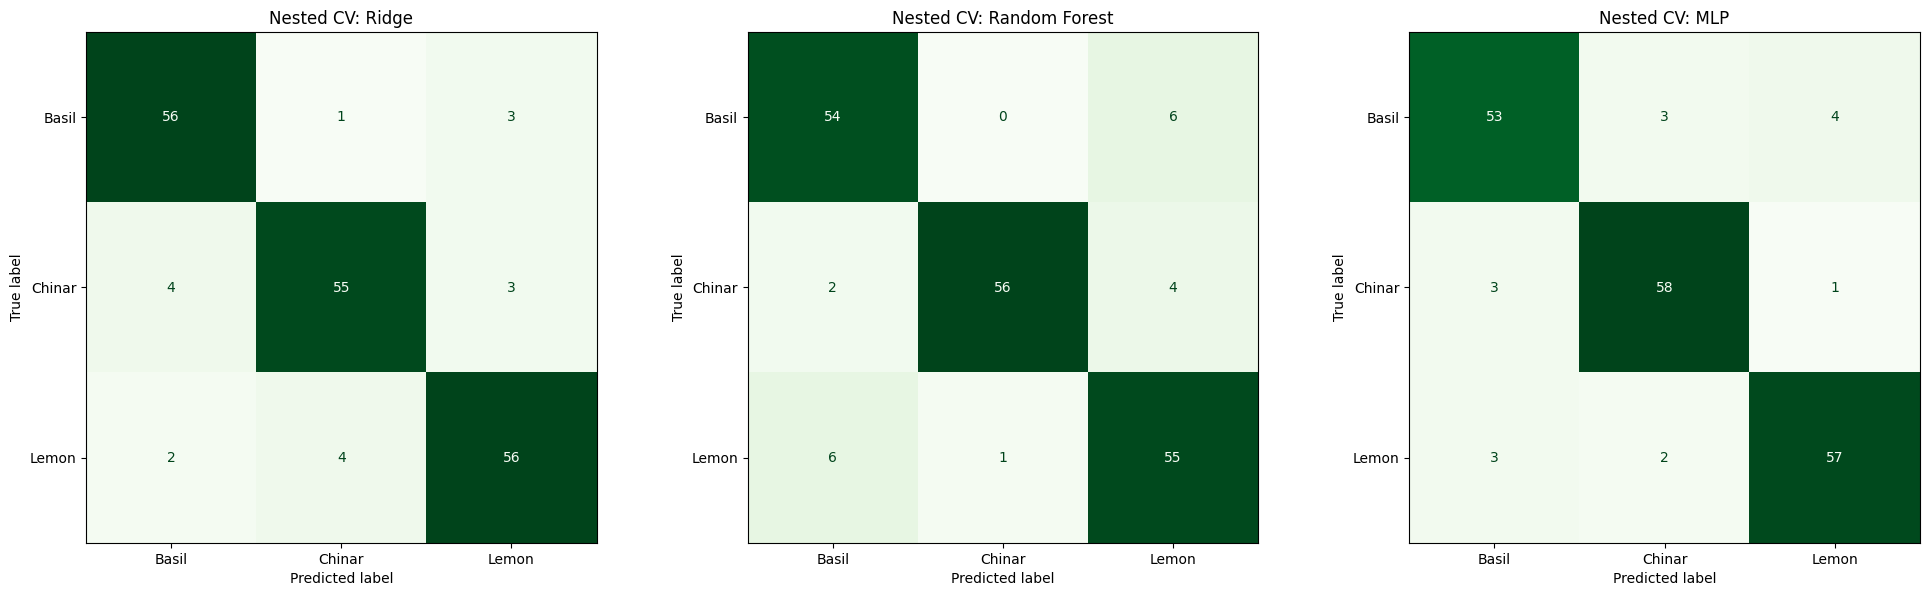

In [ ]:
#confusion matrix for the last outer fold of each classifier
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_results = [
    ("Ridge", ridge_res[1]), 
    ("Random Forest", rf_res[1]), 
    ("MLP", mlp_res[1])
]
for i, (name, y_pred) in enumerate(models_results):
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    axes[i].set_title(f"Nested CV: {name}")

plt.tight_layout()
plt.show()

## Report:

## Nested Cross-Validation Results

| Classifier | Best Hyperparameters | Mean Outer Accuracy | Std |
|---|---|---|---|
| Ridge | alpha = 1.0 | 0.9076 | 0.0237 |
| Random Forest | n_estimators = 200, max_features = 'sqrt', bootstrap = True | 0.8967 | 0.0495 |
| MLP | hidden_layer_sizes = (25,), activation = 'tanh', solver = 'adam', alpha = 1.0, validation_fraction = 0.1 | 0.9130 | 0.0344 |

**Best model: Hyperparameters and CV Accuracy**

From a purely accuracy standpoint, MLP performed the best with the highes mean accuracy of 91.30% in the neseted CV. 
Selected hyperparameters for the MLP were {'activation': 'tanh', 'alpha': 1.0, 'hidden_layer_sizes': (25,), 'solver': 'adam', 'validation_fraction': 0.1}.

**Confusion matrix**

The confusion matrix is showing how each classifier performed on each class. Which class did it get right and which class the classifier struggled with. There were 60 basil, 62 chinar and 62 lemon leaves. Overall, MLP shows the best results with only 16 times the classifier predicted wrong. It seems MLP struggled a bit with classifying Basil where the other classifiers performed slightly better in that class. But MLP was also able to differentiate chinar leaves the best among the rest of the classifiers.

**Mean accuracy of the outer folds - Explain what this value represents**

Before i was doing a standard cross-validation where I was just selecting the hyperparameters. and the accuracy was measured on the same data which the model was being trained on. So that is not a good indicator of the actual performance of the classifier. 

To understand the actual performance, I need to evaluate the performance with images not in the tuning phase. So here the mean accuracy of outer folds is the average accuracy from each fold. there were 4 folds. so the classifier was also trained and tested 4 times. with each time 1 fold is masked in the tuning to use as the test fold later.

# Discussion

## Which classifier performed best and why?
The MLP or Neural network was the overall best performing classifier with a nested cross validation accuracy of 91.3%. Followed by Ridge classifier with 90.76% and Random Forest classifier with 89.67%. 
the difference in performace between MLP and Ridge is very low. Maybe finding the non-linear relations in the data was the key to getting a slight better performance for MLP classifier. With that in mind, I think that if there were more data, ther results would be more difinitive. I still think that MLP would perform better, but I also think the ridge classifier would perform worse. 


## Limitations
- The dataset is relatively small, so estimates have high variance. while tuning, MLP needed 1000+ iterations to learn. That means the number of data was low.  
- Template matching is sensitive to leaf orientation, size and brightness. I was thinking about this a lot when I was manually seleceting the a leaf as template.
- as made blatent from the feature_importance during the random forest tuning. my classifiers were heavily focused on the RGB features. So if the same image had different lighting the values would change. if tested with them, the accuracy would be worse.

## How could results be improved?
- Add rotation-invariant texture featuresor shape features rahter than template matching.
- Augment the dataset with flips, rotations, and colour jitter. Or just as simple as changing the brightness. This would teach the model to ignore noise better.